In [94]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd

In [95]:
# Import useful data
df = pd.read_parquet('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/code/calculated_magnitudes.parquet')

feh_list = df['feh'].tolist()
logg_list = df['logg'].tolist()
alpha_list = df['alpha'].tolist()
teff_list = df['teff'].tolist()

feh = np.array(feh_list)
logg = np.array(logg_list)
alpha = np.array(alpha_list)
teff = np.array(teff_list)

gi_listP = df['giP'].tolist()
gr_listP = df['grP'].tolist()
CaHKg_listP = df['CaHKgP'].tolist()

In [96]:
# Data for the sun
T_eff_sun = 5790
logg_sun = 4.44
M_bol_sun = 4.75

Magnitude =(logg_sun-logg-np.log10(0.8)-4*np.log10(teff/T_eff_sun))


Text(0.5, 1.0, '$T_{\\text{eff}}$ vs. log(L)')

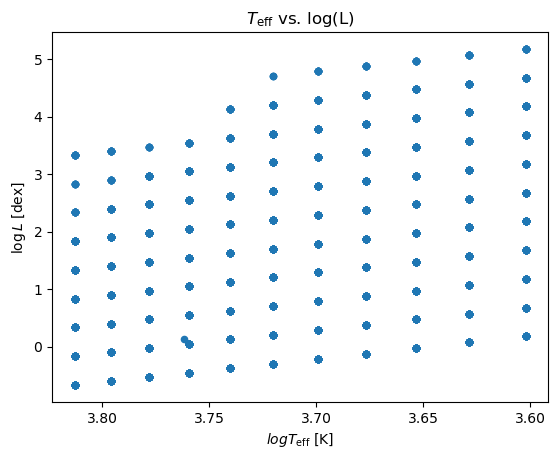

In [97]:
# Luminosity vs Temperature plot
plt.scatter(np.log10(teff),Magnitude,s=20)
plt.gca().invert_xaxis()
plt.xlabel(r'$log T_{\text{eff}} \ [\text{K}]$')
plt.ylabel(r'$\log L \ [\text{dex}]$')
plt.title(r'$T_{\text{eff}}$ vs. log(L)')

Text(0.5, 1.0, '$T_{\\text{eff}}$ vs. log(L)')

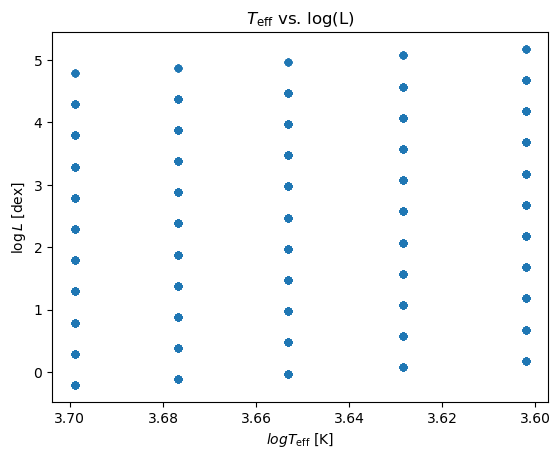

In [98]:
mask = (np.log10(teff)<3.7)
# Same plot as before with masked data
plt.scatter(np.log10(teff)[mask],Magnitude[mask],s=20)
plt.gca().invert_xaxis()
plt.xlabel(r'$log T_{\text{eff}} \ [\text{K}]$')
plt.ylabel(r'$\log L \ [\text{dex}]$')
plt.title(r'$T_{\text{eff}}$ vs. log(L)')

In [99]:
# Load isochrones
#data=np.loadtxt('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/AFEH+0.4/FeH-1.0/age10000_feh-10_afe+04_PS1.txt')
data_met2_a1 = np.loadtxt('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/AFEH+0.4/FeH-1.0/age10000_feh-10_afe+04_PS1.txt') #1
data_met2_a10 = np.loadtxt('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/AFEH+0.4/FeH-2.0/age10000_feh-20_afe+04_PS1.txt') #2
data_met05_a13 = np.loadtxt('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/AFEH+0.4/FeH-0.5/age10000_feh-05_afe+04_PS1.txt') #3
data_met4_a13 = np.loadtxt('/Users/lucakrattinger/Documents/MA1-EPFL/TP4/AFEH+0.4/FeH-4.0/age10000_feh-40_afe+04_PS1.txt') #4

# Define temperature and log g for each isochrones

t1 = data_met2_a1[:,2]
g1 = data_met2_a1[:,3]

t2 = data_met2_a10[:,2]
g2 = data_met2_a10[:,3]

t3 = data_met05_a13[:,2]
g3 = data_met05_a13[:,3]

t4 = data_met4_a13[:,2]
g4 = data_met4_a13[:,3]

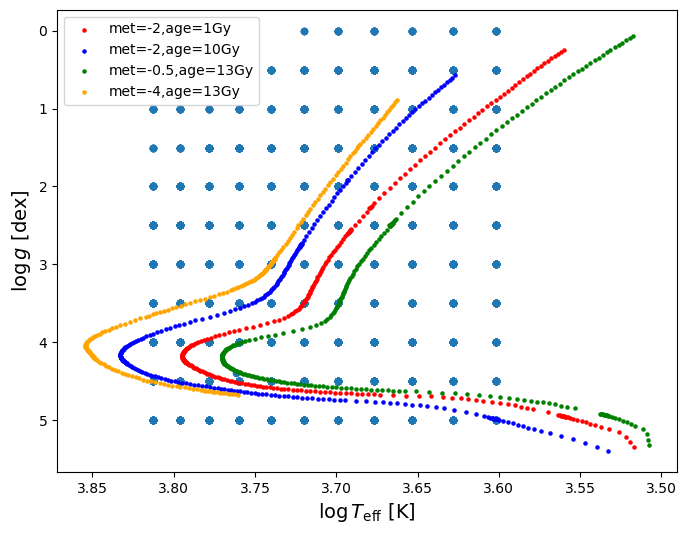

In [ ]:

# Plot isochrones and synthetic data in a log g vs Temperature plot
plt.figure(figsize=(8,6))

plt.scatter(np.log10(teff),logg,s=20)
plt.scatter(t1,g1,s=5,color='red',label='met=-2,age=1Gy')
plt.scatter(t2,g2,s=5,color='blue',label='met=-2,age=10Gy')
plt.scatter(t3,g3,s=5,color='green',label='met=-0.5,age=13Gy')
plt.scatter(t4,g4,s=5,color='orange',label='met=-4,age=13Gy')
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel(r'$\log T_{\text{eff}} \ [\text{K}]$',fontsize=14)
plt.ylabel(r'$\log g \ [\text{dex}]$',fontsize=14)
#plt.title(r'$T_{\text{eff}}$ vs. log(g)')
#plt.xlim(3.71,3.59)
plt.legend(loc='upper left')

plt.show()

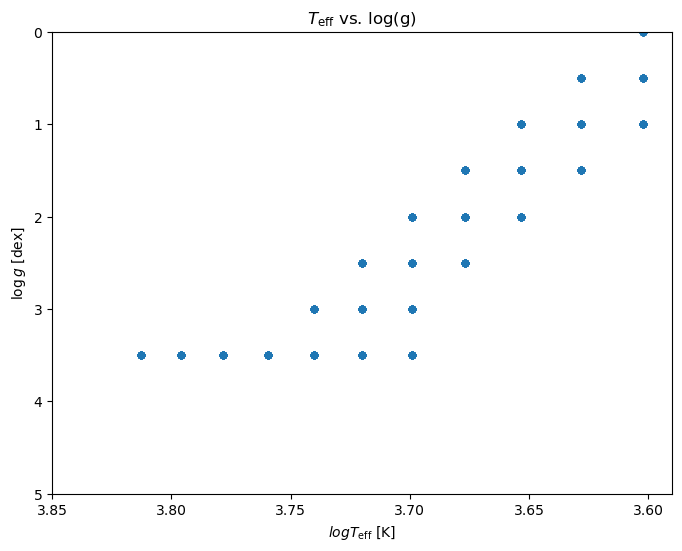

In [101]:
# Mask to choose RG stars
maskis = (
    ((teff == 4000) & (logg >= 0.0) & (logg <= 1.0))|
    ((teff == 4250) & (logg >= 0.5) & (logg <= 1.5)) |
    ((teff == 4500) & (logg >= 1.0) & (logg <= 2.0)) |
    ((teff == 4750) & (logg >= 1.5) & (logg <= 2.5)) |
    ((teff == 5000) & (logg >= 2.0) & (logg <= 3.0)) |
    ((teff == 5250) & (logg >= 2.5) & (logg <= 3.0)) |
    ((teff == 5500) & (logg == 3.0)) |
    ((teff >= 5000) & (logg == 3.5))
) #Red giant sample
selected_teff = teff[maskis]
selected_logg = logg[maskis]

# Plot RG stars

plt.figure(figsize=(8,6))

plt.scatter(np.log10(selected_teff),selected_logg,s=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel(r'$log T_{\text{eff}} \ [\text{K}]$')
plt.ylabel(r'$\log g \ [\text{dex}]$')
plt.title(r'$T_{\text{eff}}$ vs. log(g)')
plt.xlim(3.85,3.59)
plt.ylim(5,0)
#plt.legend(loc='upper right')
plt.show()

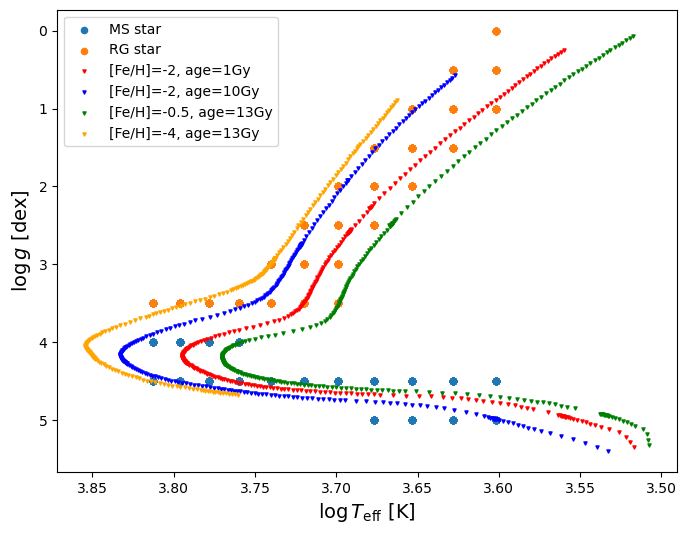

In [119]:
# Mask for MS stars
mask_ms = (
    (logg == 4.5)|
    (logg == 4) & (teff >= 5750) & (teff <= 6500 )|
    (logg == 3.5) & (teff >= 5750) & (teff <= 6500 )|
    (logg == 5) & (teff >= 4000 ) & (teff <= 4750 )
) 


selected_teff_ms = teff[mask_ms]
selected_logg_ms = logg[mask_ms]

# Plot MS stars

plt.figure(figsize=(8,6))

plt.scatter(np.log10(selected_teff_ms),selected_logg_ms,s=20,label='MS star')
plt.scatter(np.log10(selected_teff),selected_logg,s=20, label='RG star')
#plt.scatter(np.log10(selected_teff_test),selected_logg_test,s=20, label='RG star',color='black')
plt.scatter(t1,g1,s=5,color='red',marker="v",label='[Fe/H]=-2, age=1Gy')
plt.scatter(t2,g2,s=5,color='blue',marker="v",label='[Fe/H]=-2, age=10Gy')
plt.scatter(t3,g3,s=5,color='green',marker="v",label='[Fe/H]=-0.5, age=13Gy')
plt.scatter(t4,g4,s=5,color='orange',marker="v",label='[Fe/H]=-4, age=13Gy')
plt.legend(loc='upper left',fontsize=10)

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel(r'$\log T_{\text{eff}} \ [\text{K}]$',fontsize=14)
plt.ylabel(r'$\log g \ [\text{dex}]$',fontsize=14)

plt.savefig('star-selec.svg', format='svg', bbox_inches='tight')

plt.show()

/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_16229/1258261391.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


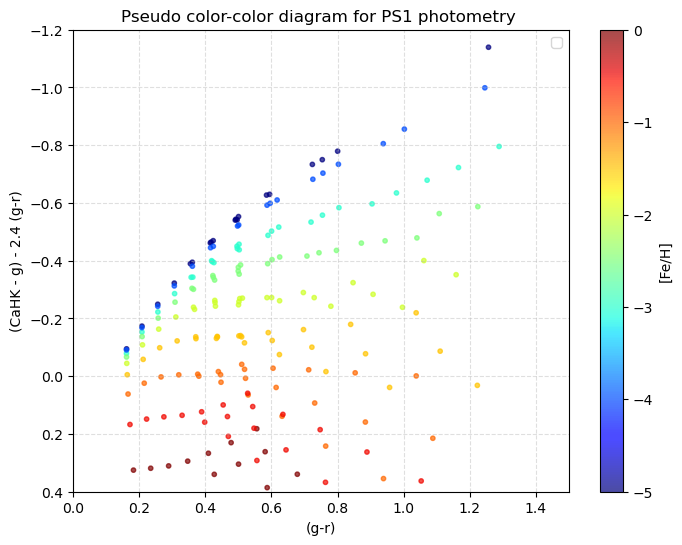

209


In [105]:
# Convert to numpy array

gi = np.array(gi_listP)
gr = np.array(gr_listP)
CaHKg = np.array(CaHKg_listP)

mask_f = maskis & (alpha==0.4)

bf = 2.4
x_axis = gr[mask_f]
y_axis = np.array(CaHKg_listP-bf*gr)[mask_f]
xlabel = f'(g-r)'
ylabel = f'(CaHK - g) - {bf} (g-r)'
color = np.array(feh_list)[mask_f]

# Plot the pseudo color-color diagram for PS1

plt.figure(figsize=(8,6))
sc = plt.scatter(x_axis,y_axis, c=color, cmap='jet', s=10, alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(f'Pseudo color-color diagram for PS1 photometry ')
plt.colorbar(label='[Fe/H]')

plt.xlim(0,1.5)
plt.ylim(0.4,-1.2)
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend()
plt.show()

print(len(x_axis))

In [ ]:
# Define Dataframe
df_new = pd.DataFrame({
    'metallicity': feh,
    'logg': logg,
    'Teff': teff,
    'alpha': alpha,
    'g_minus_r': gr,
    'g_minus_i': gi,
    'CaHK_minus_g' : CaHKg_listP
})

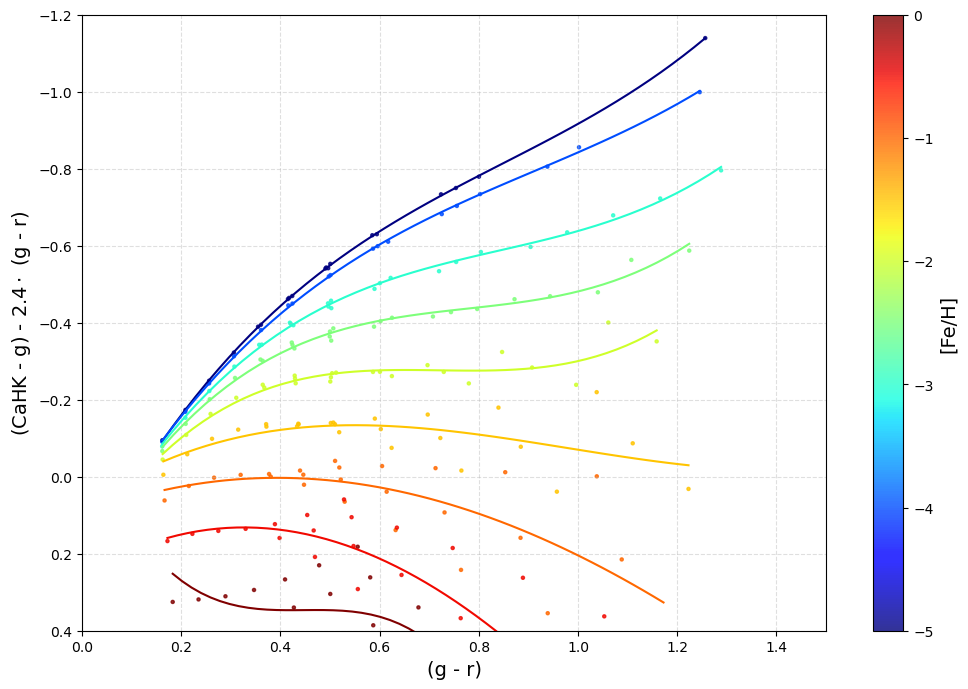

In [117]:
plt.figure(figsize=(12, 8))

# Sort metallicity 

met = np.arange(-5, 0.5, 0.5) 
cmap = plt.get_cmap('jet')

feh_arr = np.array(feh)
norm = plt.Normalize(vmin=np.min(feh_arr), vmax=np.max(feh_arr))


if 'df_new' in locals():
    for i in range(len(met)):
        # Select one metallicity slice
        df_met = df_new[df_new["metallicity"] == met[i]]
        
        if not df_met.empty:
            # Mask RG
            mask_model = (
                ((df_met['Teff'] == 4000) & (df_met['logg'] >= 0.0) & (df_met['logg'] <= 1.0)) |
                ((df_met['Teff'] == 4250) & (df_met['logg'] >= 0.5) & (df_met['logg'] <= 1.5)) |
                ((df_met['Teff'] == 4500) & (df_met['logg'] >= 1.0) & (df_met['logg'] <= 2.0)) |
                ((df_met['Teff'] == 4750) & (df_met['logg'] >= 1.5) & (df_met['logg'] <= 2.5)) |
                ((df_met['Teff'] == 5000) & (df_met['logg'] >= 2.0) & (df_met['logg'] <= 3.0)) |
                ((df_met['Teff'] == 5250) & (df_met['logg'] >= 2.5) & (df_met['logg'] <= 3.0)) |
                ((df_met['Teff'] == 5500) & (df_met['logg'] == 3.0)) |
                ((df_met['Teff'] >= 5000) & (df_met['logg'] == 3.5))
            )
                
            final_mask = mask_model & (df_met['g_minus_r'] < 1.4) & (df_met['alpha']==0.4) 
            
            # Extract Data for this specific metallicity & selection
            x_model = df_met.loc[final_mask, 'g_minus_r']
            y_model = df_met.loc[final_mask, 'CaHK_minus_g'] - 2.4 * df_met.loc[final_mask, 'g_minus_r']

            if len(x_model) > 3: # Ensure enough points to fit
                try:
                    # Polynomial Fit
                    curve = np.polyfit(x_model, y_model, 3)
                    f_curve = np.poly1d(curve)
                    
                    # Create smooth plotting range
                    x_plot = np.linspace(x_model.min(), x_model.max(), 50)
                    y_plot = f_curve(x_plot)

                    color = cmap(norm(met[i]))
                    plt.plot(x_plot, y_plot, c=color, linewidth=1.5)

                    # Residuals 
                    residual = y_model - f_curve(x_model)
                    y_upper = y_plot + np.max(residual)
                    y_lower = y_plot + np.min(residual)
                    
                    #plt.plot(x_plot, y_upper, c=color, linestyle='--', alpha=0.5)
                    #plt.plot(x_plot, y_lower, c=color, linestyle='--', alpha=0.5)
                    
                except Exception:
                    pass 


# Convert lists to arrays
teff_arr = np.array(teff)
logg_arr = np.array(logg)
gr_arr = np.array(gr)
cahk_arr = np.array(CaHKg)

# Define mask RG
maskis = (
    ((teff == 4000) & (logg >= 0.0) & (logg <= 1.0))|
    ((teff == 4250) & (logg >= 0.5) & (logg <= 1.5)) |
    ((teff == 4500) & (logg >= 1.0) & (logg <= 2.0)) |
    ((teff == 4750) & (logg >= 1.5) & (logg <= 2.5)) |
    ((teff == 5000) & (logg >= 2.0) & (logg <= 3.0)) |
    ((teff == 5250) & (logg >= 2.5) & (logg <= 3.0)) |
    ((teff == 5500) & (logg == 3.0))|
    ((teff >= 5000) & (logg == 3.5))

)
mask_f = maskis & (alpha==0.4)


# Filter
gr_selected = gr_arr[mask_f]
y_axis_selected = (cahk_arr - 2.4 * gr_arr)[mask_f]
feh_selected = feh_arr[mask_f]

# Plot
sc = plt.scatter(gr_selected, y_axis_selected, c=feh_selected, cmap=cmap, norm=norm, s=5, alpha=0.8)


plt.gca().invert_yaxis()
plt.xlabel('(g - r)',fontsize=14)
plt.ylabel(r'(CaHK - g) - $2.4 \cdot$ (g - r)',fontsize=14)
#plt.title('Color-Color diagram')
plt.grid(True, linestyle='--', alpha=0.4)
cbar = plt.colorbar(sc, label='[Fe/H]')
cbar.set_label(label='[Fe/H]', fontsize=14)
plt.xlim(0, 1.5)
plt.ylim(0.4, -1.2)
plt.savefig('RG-fit.svg', format='svg', bbox_inches='tight')
plt.show()

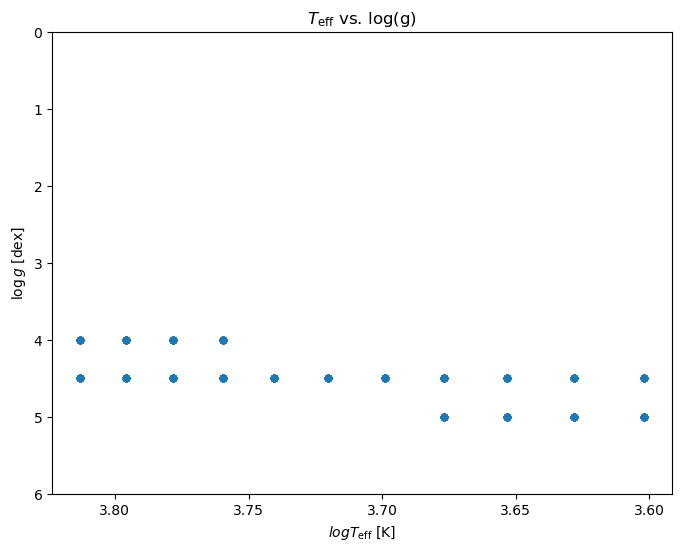

In [ ]:
# Do the same as before but with MS instead of RGB

mask_ms = (
    (logg == 4.5)|
    (logg == 4) & (teff >= 5750) & (teff <= 6500 )|
    (logg == 5) & (teff >= 4000 ) & (teff <= 4750 )
) 

selected_teff_ms = teff[mask_ms]
selected_logg_ms = logg[mask_ms]

# Plot MS stars
plt.figure(figsize=(8,6))

plt.scatter(np.log10(selected_teff_ms),selected_logg_ms,s=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel(r'$log T_{\text{eff}} \ [\text{K}]$')
plt.ylabel(r'$\log g \ [\text{dex}]$')
plt.title(r'$T_{\text{eff}}$ vs. log(g)')
plt.ylim(6,0)
#plt.legend(loc='upper right')
plt.show()

/var/folders/zt/ylf2qf8x2d5dr9ph82k39mr80000gn/T/ipykernel_16229/723070926.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


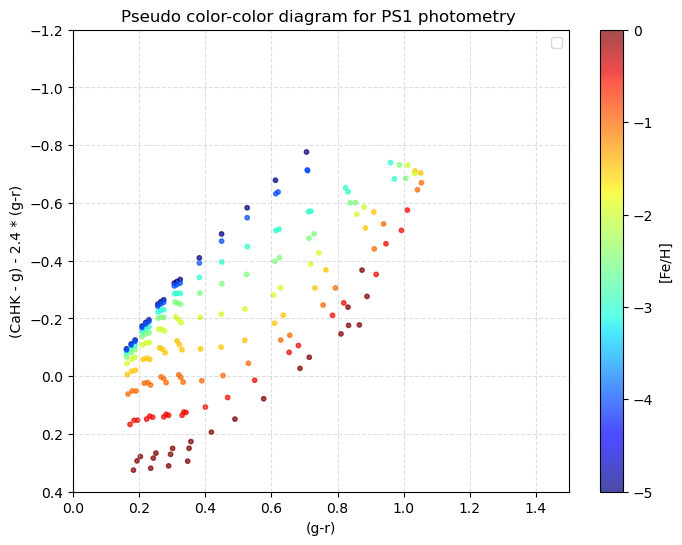

197


In [ ]:
gi = np.array(gi_listP)
gr = np.array(gr_listP)
CaHKg = np.array(CaHKg_listP)

mask_msf = mask_ms & (alpha==0.4)

bf = 2.4
x_axis = gr[mask_msf]
y_axis = np.array(CaHKg_listP-bf*gr)[mask_msf]
xlabel = f'(g-r)'
ylabel = f'(CaHK - g) - {bf} * (g-r)'
color = np.array(feh_list)[mask_msf]

# Plot the pseudo color-color diagram for PS1 for MS stars

plt.figure(figsize=(8,6))
sc = plt.scatter(x_axis,y_axis, c=color, cmap='jet', s=10, alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(f'Pseudo color-color diagram for PS1 photometry ')
plt.colorbar(label='[Fe/H]')

plt.xlim(0,1.5)
plt.ylim(0.4,-1.2)
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend()
plt.show()

print(len(x_axis))

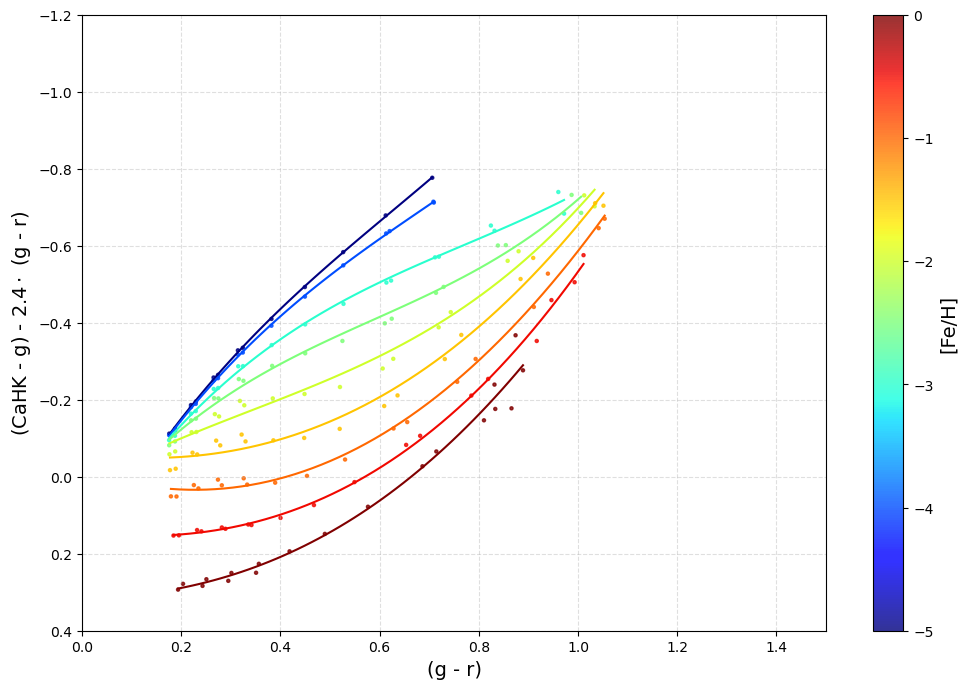

In [118]:
plt.figure(figsize=(12, 8))

met = np.arange(-5, 0.5, 0.5) 
cmap = plt.get_cmap('jet')

feh_arr = np.array(feh)
norm = plt.Normalize(vmin=np.min(feh_arr), vmax=np.max(feh_arr))


if 'df_new' in locals():
    for i in range(len(met)):
        # Select one metallicity slice
        df_met = df_new[df_new["metallicity"] == met[i]]
        
        if not df_met.empty:
    
            # MS Mask
            mask_model = (
                (df_met['logg'] == 4.5)|
                (df_met['logg'] == 4) & (df_met['Teff'] >= 5750) & (df_met['Teff'] <= 6500 )|
                (df_met['logg'] == 5) & (df_met['Teff'] >= 4000 ) & (df_met['Teff'] <= 4750 )
            ) 
            
            final_mask = mask_model & (df_met['g_minus_r'] < 1.4) & (df_met['alpha']==0.4) 
            
            # Extract Data for this specific metallicity & selection
            x_model = df_met.loc[final_mask, 'g_minus_r']
            y_model = df_met.loc[final_mask, 'CaHK_minus_g'] - 2.4 * df_met.loc[final_mask, 'g_minus_r']

            if len(x_model) > 3: # Ensure enough points to fit
                try:
                    # Polynomial Fit
                    curve = np.polyfit(x_model, y_model, 3)
                    f_curve = np.poly1d(curve)
                    
                    # Create smooth plotting range
                    x_plot = np.linspace(x_model.min(), x_model.max(), 50)
                    y_plot = f_curve(x_plot)

                    color = cmap(norm(met[i]))
                    plt.plot(x_plot, y_plot, c=color, linewidth=1.5)

                    # Residuals 
                    residual = y_model - f_curve(x_model)
                    y_upper = y_plot + np.max(residual)
                    y_lower = y_plot + np.min(residual)
                    
                    #plt.plot(x_plot, y_upper, c=color, linestyle='--', alpha=0.5)
                    #plt.plot(x_plot, y_lower, c=color, linestyle='--', alpha=0.5)
                    
                except Exception:
                    pass 


# Convert lists to arrays
teff_arr = np.array(teff)
logg_arr = np.array(logg)
gr_arr = np.array(gr)
cahk_arr = np.array(CaHKg)

# MS mask
mask_ms = (
    (logg == 4.5)|
    (logg == 4) & (teff >= 5750) & (teff <= 6500 )|
    (logg == 5) & (teff >= 4000 ) & (teff <= 4750 )
) 

mask_f = mask_ms & (alpha==0.4)


# Filter
gr_selected = gr_arr[mask_f]
y_axis_selected = (cahk_arr - 2.4 * gr_arr)[mask_f]
feh_selected = feh_arr[mask_f]

# Plot
sc = plt.scatter(gr_selected, y_axis_selected, c=feh_selected, cmap=cmap, norm=norm, s=5, alpha=0.8)


plt.gca().invert_yaxis()
plt.xlabel(r'(g - r)',fontsize=14)
plt.ylabel(r'(CaHK - g) - $2.4 \cdot$ (g - r)',fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
cbar = plt.colorbar(sc, label='[Fe/H]')
cbar.set_label(label='[Fe/H]', fontsize=14)

plt.xlim(0, 1.5)
plt.ylim(0.4, -1.2)

plt.savefig('MS-fit.svg', format='svg', bbox_inches='tight')

plt.show()

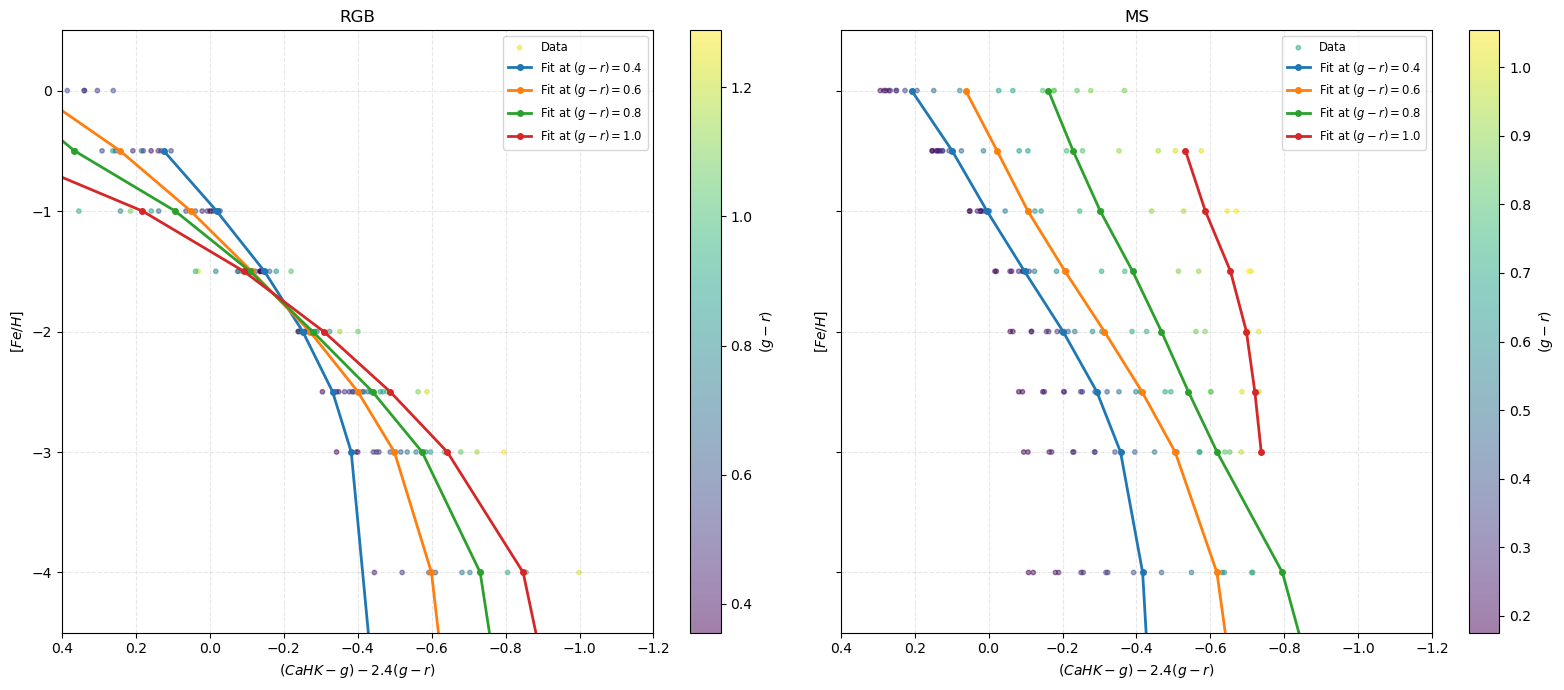

In [ ]:
# Define the masks 

# RGB Mask
mask_rgb_model = (
    ((df_new['Teff'] == 4000) & (df_new['logg'] >= 0.0) & (df_new['logg'] <= 1.0)) |
    ((df_new['Teff'] == 4250) & (df_new['logg'] >= 0.5) & (df_new['logg'] <= 1.5)) |
    ((df_new['Teff'] == 4500) & (df_new['logg'] >= 1.0) & (df_new['logg'] <= 2.0)) |
    ((df_new['Teff'] == 4750) & (df_new['logg'] >= 1.5) & (df_new['logg'] <= 2.5)) |
    ((df_new['Teff'] == 5000) & (df_new['logg'] >= 2.0) & (df_new['logg'] <= 3.0)) |
    ((df_new['Teff'] == 5250) & (df_new['logg'] >= 2.5) & (df_new['logg'] <= 3.0)) |
    ((df_new['Teff'] == 5500) & (df_new['logg'] == 3.0))
)
mask_rgb = mask_rgb_model & (df_new['g_minus_r'] < 1.4) & (df_new['alpha'] == 0.4)

# MS Mask
mask_ms_model = (
    (df_new['logg'] == 4.5) |
    ((df_new['logg'] == 4) & (df_new['Teff'] >= 5750) & (df_new['Teff'] <= 6500)) |
    ((df_new['logg'] == 5) & (df_new['Teff'] >= 4000) & (df_new['Teff'] <= 4750))
)
mask_ms = mask_ms_model & (df_new['g_minus_r'] < 1.4) & (df_new['alpha'] == 0.4)

# Setup Plotting

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
met_range = np.arange(-5, 0.5, 0.5) 
bf = 2.4
ref_colors = [0.4, 0.6, 0.8, 1.0] # Fixed colors to show calibration tracks

# Helper function to extract fits and plot
def plot_calibration(ax, mask, title):
    # Scatter Plot of Raw Data
    # Calculate the index manually for the scatter
    y_data = df_new.loc[mask, 'metallicity']
    x_data = df_new.loc[mask, 'CaHK_minus_g'] - bf * df_new.loc[mask, 'g_minus_r']
    c_data = df_new.loc[mask, 'g_minus_r']
    
    sc = ax.scatter(x_data, y_data, c=c_data, cmap='viridis', s=10, alpha=0.5, label='Data')
    plt.colorbar(sc, ax=ax, label=r'$(g-r)$')

    # Generate Calibration Lines
    # Dictionaries to store points for the lines: {color: ([index_vals], [feh_vals])}
    calib_lines = {c: {'x': [], 'y': []} for c in ref_colors}

    for m in met_range:
        # Slice data by metallicity
        df_slice = df_new[mask & (df_new["metallicity"] == m)]
        
        if len(df_slice) > 3:
            x_fit = df_slice['g_minus_r']
            y_fit = df_slice['CaHK_minus_g'] - bf * df_slice['g_minus_r']
            
            try:
                # Calculate the polynomial fit for this metallicity bin
                curve = np.polyfit(x_fit, y_fit, 3)
                f_curve = np.poly1d(curve)
                
                # Evaluate polynomial at reference colors and store
                for c in ref_colors:
                    # Only plot if reference color is within reasonable range of data slice
                    if x_fit.min() <= c <= x_fit.max() + 0.1:
                        calib_lines[c]['x'].append(f_curve(c))
                        calib_lines[c]['y'].append(m)
            except:
                pass

    # Plot the collected Calibration Lines
    for c, data in calib_lines.items():
        if len(data['x']) > 0:
            # Sort by Metallicity to ensure line connects properly
             sorted_pairs = sorted(zip(data['y'], data['x']))
             ys = [p[0] for p in sorted_pairs] # FeH
             xs = [p[1] for p in sorted_pairs] # Index
             
             ax.plot(xs, ys, linewidth=2, marker='o', markersize=4, label=f'Fit at $(g-r)={c}$')

    ax.set_ylabel(r'$[Fe/H]$')
    ax.set_xlabel(r'$(CaHK - g) - 2.4 (g-r)$')
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(fontsize='small')
    
    # Set limits
    ax.set_ylim(-4.5, 0.5)
    ax.set_xlim(0.4, -1.2) 

# Plot
plot_calibration(axes[0], mask_rgb, r'RGB')
plot_calibration(axes[1], mask_ms, r'MS')

plt.tight_layout()
plt.show()